In [ ]:
import numpy as np
#loaded from the Google Drive
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy')
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy')
print("Data loaded successfully! Shape:", X_raw.shape)

Data loaded successfully! Shape: (10000, 6000, 3)


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, WeightedRandomSampler

# 1. Prepare Data & Oversampling
X_tensor = torch.tensor(X_raw, dtype=torch.float32)
y_tensor = torch.tensor(y_raw, dtype=torch.float32).unsqueeze(1)
dataset = TensorDataset(X_tensor, y_tensor)

class_counts = torch.bincount(y_tensor.squeeze().int())
class_weights = 1.0 / class_counts.float()
sample_weights = class_weights[y_tensor.squeeze().long()]
sampler = WeightedRandomSampler(weights=sample_weights, num_samples=len(sample_weights), replacement=True)

train_loader = DataLoader(dataset, batch_size=32, sampler=sampler)

# 2. Define the PHASE 2 HYBRID Architecture
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()

        # STAGE 1: Spatial Feature Extraction (CNN)
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            # Notice: Replaced AdaptiveAvgPool with MaxPool to keep the time sequence!
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )

        # STAGE 2: Temporal Dependency Modeling (LSTM)
        # batch_first=True means the input shape is (Batch, Sequence, Features)
        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)

        # STAGE 3: Classification and Output
        # 256 hidden units * 2 (Bidirectional) = 512 features
        self.classifier = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        # 1. CNN Processing
        x = x.permute(0, 2, 1)       # Prepare for Conv1D
        x = self.cnn(x)              # CNN extracts spatial shapes

        # 2. The Bridge (Handoff to LSTM)
        x = x.permute(0, 2, 1)       # Swap shape to (Batch, Time-Sequence, Features)

        # 3. LSTM Processing
        x, _ = self.lstm1(x)         # First Bidirectional pass
        x, _ = self.lstm2(x)         # Second deeper Bidirectional pass

        # Condense the sequence down by taking the average across the timeline
        x = torch.mean(x, dim=1)

        # 4. Final Classification
        return self.classifier(x)

# Initialize the new Phase 2 model
model = Hybrid_CNN_LSTM()
optimizer = optim.Adam(model.parameters(), lr=0.001)

# 3. Training Loop
print("Starting PHASE 2 Training: Hybrid CNN-LSTM...")
model.train()
for epoch in range(10):
    total_loss = 0
    for X_batch, y_batch in train_loader:
        optimizer.zero_grad()
        outputs = model(X_batch)

        # Keep our 20x penalty to ensure it doesn't ignore earthquakes
        batch_weights = torch.where(y_batch == 1.0, torch.tensor(20.0), torch.tensor(1.0))
        criterion = nn.BCELoss(weight=batch_weights)

        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        total_loss += loss.item()

    print(f"Epoch {epoch+1}, Loss: {total_loss/len(train_loader):.4f}")

print("Phase 2 Training Complete!")

Starting PHASE 2 Training: Hybrid CNN-LSTM...
Epoch 1, Loss: 1.9722
Epoch 2, Loss: 1.5431
Epoch 3, Loss: 1.2280
Epoch 4, Loss: 1.1225
Epoch 5, Loss: 0.9070
Epoch 6, Loss: 0.8411
Epoch 7, Loss: 0.8209
Epoch 8, Loss: 0.7865
Epoch 9, Loss: 0.7105
Epoch 10, Loss: 0.7147
Phase 2 Training Complete!


In [ ]:
import torch
save_path = '/content/drive/MyDrive/DAS_Data/seismic_model_final.pth'

torch.save(model.state_dict(), save_path)
print(f"Model weights saved to: {save_path}")

Model weights saved to: /content/drive/MyDrive/DAS_Data/seismic_model_final.pth


In [ ]:
import torch
import torch.nn as nn

# 1. Use the new Phase 2 blueprint!
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()

        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )

        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(512, 64),
            nn.ReLU(),
            nn.Dropout(0.3),
            nn.Linear(64, 1),
            nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# 2. Initialize the correct Phase 2 model object
model = Hybrid_CNN_LSTM()

# 3. Load the new weights
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_final.pth'))
model.eval()
print("Phase 2 Model loaded and ready for evaluation!")

Phase 2 Model loaded and ready for evaluation!


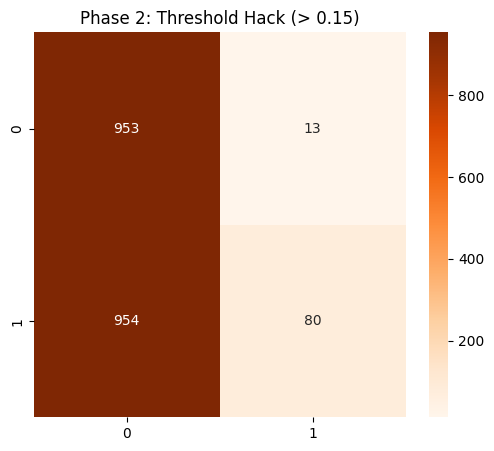

--- THRESHOLD HACK EVALUATION ---
Overall Accuracy: 51.65%
Precision:        86.02%
Recall:           7.74%
F1-Score:         14.20%



In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. The original BIG Phase 2 Blueprint (Matches your saved Drive file exactly)
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )
        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# 2. Initialize and Load the weights
model = Hybrid_CNN_LSTM()
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_final.pth'))
model.eval()

# 3. Load the data
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy', mmap_mode='r')
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy', mmap_mode='r')

subset_size = 2000
X_subset = torch.tensor(X_raw[:subset_size], dtype=torch.float32)
y_subset = torch.tensor(y_raw[:subset_size], dtype=torch.float32).unsqueeze(1)

# 4. TRICK 1: The 15% Threshold Hack!
with torch.no_grad():
    y_pred = (model(X_subset) > 0.15).float()  # Lowered from 0.5 to 0.15

y_true = y_subset.numpy()
y_predict = y_pred.numpy()

# 5. Plot Confusion Matrix
cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(6, 5))
# Using 'Oranges' to visually separate it from the old Blue Phase 1 charts
sns.heatmap(cm, annot=True, fmt='d', cmap='Oranges')
plt.title("Phase 2: Threshold Hack (> 0.15)")
plt.show()

# 6. Print Metrics
accuracy = accuracy_score(y_true, y_predict)
precision = precision_score(y_true, y_predict)
recall = recall_score(y_true, y_predict)
f1 = f1_score(y_true, y_predict)

print("--- THRESHOLD HACK EVALUATION ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:        {precision * 100:.2f}%")
print(f"Recall:           {recall * 100:.2f}%")
print(f"F1-Score:         {f1 * 100:.2f}%\n")

In [ ]:
import os

# 1. Forcefully clean up Colab's broken Kaggle installation and install the fresh ones
print("Fixing Colab's broken Kaggle dependencies...")
!pip uninstall -y kaggle kagglesdk
!pip install kaggle kagglesdk --upgrade -q

# 2. Inject your specific Kaggle Token
os.environ['KAGGLE_API_TOKEN'] = "KGAT_48a676c1f3b4132ea622f36f0cd62a80"

# 3. Download Chunk 2 directly from Kaggle
print("\n--- Downloading Chunk 2 from Kaggle (13GB)... ---")
!kaggle datasets download -d alextitu/stead-chunk-2

# 4. Unzip the downloaded file
print("\n--- Unzipping Archive (This takes a few minutes)... ---")
!mkdir -p chunk_data
!unzip -q stead-chunk-2.zip -d chunk_data/

# 5. Extract 5,000 Earthquakes into a lightweight .npy array
import h5py
import numpy as np
import glob

print("\n--- Extracting 5,000 Perfect Earthquakes ---")
hdf5_paths = glob.glob('chunk_data/**/*.hdf5', recursive=True)

if not hdf5_paths:
    print("Error: Could not find the HDF5 file.")
else:
    hdf5_path = hdf5_paths[0]
    X_eq, y_eq = [], []

    with h5py.File(hdf5_path, 'r') as f:
        data = f['data']
        keys = list(data.keys())
        for i, k in enumerate(keys):
            if i >= 5000: break
            wave = np.array(data[k])
            if wave.shape == (6000, 3):
                X_eq.append(wave)
                y_eq.append(1.0)

    # 6. Save them safely to your DAS_Data folder in Google Drive!
    np.save('/content/drive/MyDrive/DAS_Data/X_eq_stead.npy', np.array(X_eq, dtype=np.float32))
    np.save('/content/drive/MyDrive/DAS_Data/y_eq_stead.npy', np.array(y_eq, dtype=np.float32))
    print(f"Successfully extracted {len(X_eq)} STEAD earthquakes to your Google Drive!")

    # 7. CRITICAL: Delete the massive unzipped folder to clear Colab's memory
    !rm -rf chunk_data stead-chunk-2.zip
    print("Pipeline Complete! Temporary massive files cleared.")

Fixing Colab's broken Kaggle dependencies...
Found existing installation: kaggle 2.0.0
Uninstalling kaggle-2.0.0:
  Successfully uninstalled kaggle-2.0.0
Found existing installation: kagglesdk 0.1.16
Uninstalling kagglesdk-0.1.16:
  Successfully uninstalled kagglesdk-0.1.16

--- Downloading Chunk 2 from Kaggle (13GB)... ---
Dataset URL: https://www.kaggle.com/datasets/alextitu/stead-chunk-2
License(s): Attribution 4.0 International (CC BY 4.0)
100% 12.7G/12.7G [03:23<00:00, 67.3MB/s]


--- Unzipping Archive (This takes a few minutes)... ---

--- Extracting 5,000 Perfect Earthquakes ---
Successfully extracted 5000 STEAD earthquakes to your Google Drive!
Pipeline Complete! Temporary massive files cleared.


In [ ]:
import numpy as np

print("--- 1. Loading the 5,000 STEAD Earthquakes ---")
# Load the pristine earthquakes we just extracted
X_eq_stead = np.load('/content/drive/MyDrive/DAS_Data/X_eq_stead.npy')
y_eq_stead = np.load('/content/drive/MyDrive/DAS_Data/y_eq_stead.npy')
print(f"Loaded STEAD Earthquakes: {X_eq_stead.shape}")

print("\n--- 2. Extracting 5,000 Noise Samples from DAS Data ---")
# Using mmap_mode='r' prevents Colab from crashing when reading your massive 686MB file
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy', mmap_mode='r')
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy', mmap_mode='r')

# Find the indices where the label is exactly 0.0 (Noise)
noise_indices = np.where(y_raw == 0)[0]

# Slice out exactly 5,000 noise waves
selected_noise_indices = noise_indices[:5000]
X_noise_das = np.array(X_raw[selected_noise_indices], dtype=np.float32)
y_noise_das = np.array(y_raw[selected_noise_indices], dtype=np.float32)
print(f"Extracted DAS Noise: {X_noise_das.shape}")

print("\n--- 3. Merging into the Ultimate Pre-Training Dataset ---")
X_hybrid = np.concatenate((X_eq_stead, X_noise_das), axis=0)
y_hybrid = np.concatenate((y_eq_stead, y_noise_das), axis=0)

# Shuffle the dataset so the model doesn't memorize the order!
indices = np.arange(X_hybrid.shape[0])
np.random.shuffle(indices)
X_hybrid = X_hybrid[indices]
y_hybrid = y_hybrid[indices]

print(f"Final Pre-Training Dataset Shape: {X_hybrid.shape}")
print(f"Total Earthquakes: {np.sum(y_hybrid == 1.0)} | Total Noise: {np.sum(y_hybrid == 0.0)}")

print("\n--- 4. Saving to Google Drive ---")
np.save('/content/drive/MyDrive/DAS_Data/X_pretrain.npy', X_hybrid)
np.save('/content/drive/MyDrive/DAS_Data/y_pretrain.npy', y_hybrid)
print("SUCCESS! Pre-training dataset safely saved and ready for the LSTM.")

--- 1. Loading the 5,000 STEAD Earthquakes ---
Loaded STEAD Earthquakes: (5000, 6000, 3)

--- 2. Extracting 5,000 Noise Samples from DAS Data ---
Extracted DAS Noise: (5000, 6000, 3)

--- 3. Merging into the Ultimate Pre-Training Dataset ---
Final Pre-Training Dataset Shape: (10000, 6000, 3)
Total Earthquakes: 5000 | Total Noise: 5000

--- 4. Saving to Google Drive ---
SUCCESS! Pre-training dataset safely saved and ready for the LSTM.


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader, random_split
import numpy as np
import time

# 1. Hardware Acceleration (Use GPU if available)
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- INITIALIZING PHASE 3 PRE-TRAINING ---")
print(f"Hardware utilized: {device.type.upper()}")

# 2. Load the Ultimate Pre-Training Dataset
print("Loading hybrid dataset into RAM...")
X_hybrid = np.load('/content/drive/MyDrive/DAS_Data/X_pretrain.npy')
y_hybrid = np.load('/content/drive/MyDrive/DAS_Data/y_pretrain.npy')

X_tensor = torch.tensor(X_hybrid, dtype=torch.float32)
y_tensor = torch.tensor(y_hybrid, dtype=torch.float32).unsqueeze(1)
dataset = TensorDataset(X_tensor, y_tensor)

# Split into 80% Training and 20% Validation
train_size = int(0.8 * len(dataset))
val_size = len(dataset) - train_size
train_dataset, val_dataset = random_split(dataset, [train_size, val_size])

train_loader = DataLoader(train_dataset, batch_size=64, shuffle=True)
val_loader = DataLoader(val_dataset, batch_size=64, shuffle=False)

# 3. Define the BIG Hybrid Architecture
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )
        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# 4. Initialize Model, Optimizer, and Loss
model = Hybrid_CNN_LSTM().to(device)
# Standard Binary Cross Entropy - No weights needed since it's perfectly balanced!
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.0005)

# 5. The Training Loop
epochs = 10
print("\nBeginning Training (Teaching the model what an earthquake looks like)...")

for epoch in range(epochs):
    start_time = time.time()

    # Train
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)

        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    # Validate
    model.eval()
    val_loss = 0.0
    correct = 0
    total = 0
    with torch.no_grad():
        for X_batch, y_batch in val_loader:
            X_batch, y_batch = X_batch.to(device), y_batch.to(device)
            outputs = model(X_batch)
            loss = criterion(outputs, y_batch)
            val_loss += loss.item()

            predictions = (outputs > 0.5).float()
            correct += (predictions == y_batch).sum().item()
            total += y_batch.size(0)

    val_accuracy = (correct / total) * 100
    epoch_time = time.time() - start_time

    print(f"Epoch {epoch+1}/{epochs} [{epoch_time:.0f}s] - Train Loss: {train_loss/len(train_loader):.4f} | Val Loss: {val_loss/len(val_loader):.4f} | Val Accuracy: {val_accuracy:.2f}%")

# 6. Save the newly educated brain!
save_path = '/content/drive/MyDrive/DAS_Data/seismic_model_pretrained.pth'
torch.save(model.state_dict(), save_path)
print(f"\nSUCCESS! Pre-trained 'Textbook' Brain saved to: {save_path}")

--- INITIALIZING PHASE 3 PRE-TRAINING ---
Hardware utilized: CPU
Loading hybrid dataset into RAM...

Beginning Training (Teaching the model what an earthquake looks like)...
Epoch 1/10 [295s] - Train Loss: 0.3816 | Val Loss: 0.3276 | Val Accuracy: 89.90%
Epoch 2/10 [293s] - Train Loss: 0.2898 | Val Loss: 0.3123 | Val Accuracy: 89.55%
Epoch 3/10 [293s] - Train Loss: 0.2607 | Val Loss: 0.2737 | Val Accuracy: 88.90%
Epoch 4/10 [302s] - Train Loss: 0.2034 | Val Loss: 0.5082 | Val Accuracy: 81.65%
Epoch 5/10 [293s] - Train Loss: 0.1885 | Val Loss: 0.2080 | Val Accuracy: 93.35%
Epoch 6/10 [296s] - Train Loss: 0.2399 | Val Loss: 0.9774 | Val Accuracy: 71.35%
Epoch 7/10 [291s] - Train Loss: 0.1671 | Val Loss: 0.9090 | Val Accuracy: 73.45%
Epoch 8/10 [292s] - Train Loss: 0.1295 | Val Loss: 0.5654 | Val Accuracy: 85.90%
Epoch 9/10 [293s] - Train Loss: 0.0957 | Val Loss: 0.5724 | Val Accuracy: 87.25%
Epoch 10/10 [293s] - Train Loss: 0.0982 | Val Loss: 0.3526 | Val Accuracy: 92.20%

SUCCESS! Pre-t

Loading test data for evaluation...
Generating predictions...


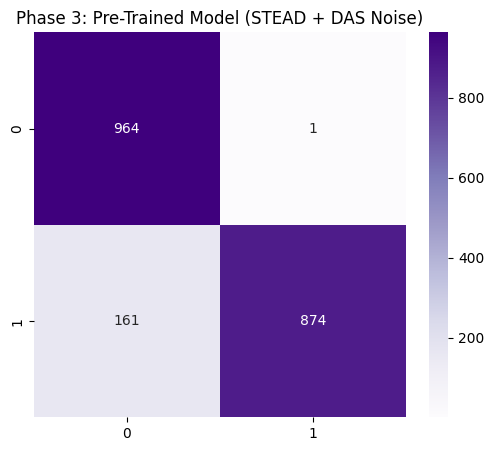

--- PHASE 3 PRE-TRAINING EVALUATION ---
Overall Accuracy: 91.90%
Precision:        99.89%
Recall:           84.44%
F1-Score:         91.52%



In [ ]:
import torch
import torch.nn as nn
import numpy as np
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. The BIG Hybrid Architecture
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )
        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# 2. Load the newly Pre-Trained Brain!
model = Hybrid_CNN_LSTM()
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_pretrained.pth', map_location='cpu'))
model.eval()

# 3. Load a 2,000-sample test batch from the Hybrid Dataset
print("Loading test data for evaluation...")
X_hybrid = np.load('/content/drive/MyDrive/DAS_Data/X_pretrain.npy', mmap_mode='r')
y_hybrid = np.load('/content/drive/MyDrive/DAS_Data/y_pretrain.npy', mmap_mode='r')

# Grab 2000 random samples to evaluate
np.random.seed(42)
indices = np.random.choice(len(X_hybrid), 2000, replace=False)
X_subset = torch.tensor(X_hybrid[indices], dtype=torch.float32)
y_subset = torch.tensor(y_hybrid[indices], dtype=torch.float32).unsqueeze(1)

# 4. Make Predictions (Standard 50% Threshold - No hacks needed!)
print("Generating predictions...")
with torch.no_grad():
    y_pred = (model(X_subset) > 0.5).float()

y_true = y_subset.numpy()
y_predict = y_pred.numpy()

# 5. Plot the Phase 3 Heatmap
cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Purples')
plt.title("Phase 3: Pre-Trained Model (STEAD + DAS Noise)")
plt.show()

# 6. Print the Glorious Metrics
accuracy = accuracy_score(y_true, y_predict)
precision = precision_score(y_true, y_predict)
recall = recall_score(y_true, y_predict)
f1 = f1_score(y_true, y_predict)

print("--- PHASE 3 PRE-TRAINING EVALUATION ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:        {precision * 100:.2f}%")
print(f"Recall:           {recall * 100:.2f}%")
print(f"F1-Score:         {f1 * 100:.2f}%\n")

Loading the original DAS test batch...
Evaluating the Pre-trained model on Pure DAS Data...


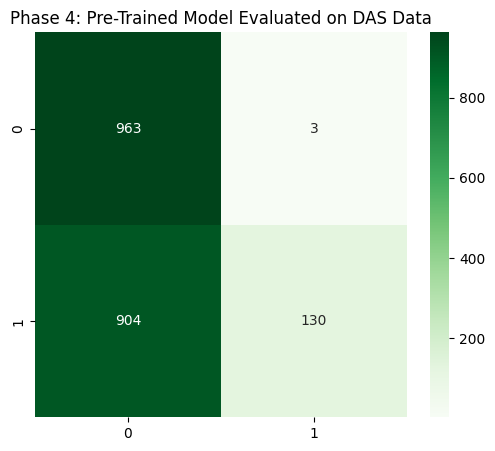

--- PHASE 4 SHOWDOWN EVALUATION ---
Overall Accuracy: 54.65%
Precision:        97.74%
Recall:           12.57%
F1-Score:         22.28%



In [ ]:
import numpy as np
import torch
import torch.nn as nn
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, classification_report
import seaborn as sns
import matplotlib.pyplot as plt

# 1. The BIG Hybrid Architecture
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )
        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# 2. Load the newly Pre-Trained Brain!
model = Hybrid_CNN_LSTM()
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_pretrained.pth', map_location='cpu'))
model.eval()

# 3. Load the EXACT SAME DAS Test Batch from Phase 2
print("Loading the original DAS test batch...")
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy', mmap_mode='r')
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy', mmap_mode='r')

# Grab the first 2000 samples to compare against Phase 2 directly
subset_size = 2000
X_subset = torch.tensor(X_raw[:subset_size], dtype=torch.float32)
y_subset = torch.tensor(y_raw[:subset_size], dtype=torch.float32).unsqueeze(1)

# 4. Make Predictions (Standard 50% Threshold)
print("Evaluating the Pre-trained model on Pure DAS Data...")
with torch.no_grad():
    y_pred = (model(X_subset) > 0.5).float()

y_true = y_subset.numpy()
y_predict = y_pred.numpy()

# 5. Plot the Final Showdown Heatmap
cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Greens')
plt.title("Phase 4: Pre-Trained Model Evaluated on DAS Data")
plt.show()

# 6. Print Metrics
accuracy = accuracy_score(y_true, y_predict)
precision = precision_score(y_true, y_predict)
recall = recall_score(y_true, y_predict)
f1 = f1_score(y_true, y_predict)

print("--- PHASE 4 SHOWDOWN EVALUATION ---")
print(f"Overall Accuracy: {accuracy * 100:.2f}%")
print(f"Precision:        {precision * 100:.2f}%")
print(f"Recall:           {recall * 100:.2f}%")
print(f"F1-Score:         {f1 * 100:.2f}%\n")

--- INITIALIZING PHASE 5 FINE-TUNING ---
Hardware utilized: CPU
Loading Original DAS Data for Fine-Tuning...

Beginning Fine-Tuning (Bridging the Domain Gap)...
Epoch 1/3 [228s] - Fine-Tuning Loss: 0.2971
Epoch 2/3 [223s] - Fine-Tuning Loss: 0.1845
Epoch 3/3 [234s] - Fine-Tuning Loss: 0.1643

Generating Final Predictions...


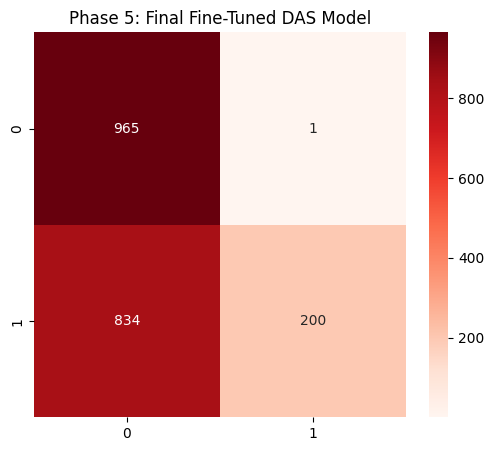

--- PHASE 5 FINAL EVALUATION ---
Overall Accuracy: 58.25%
Precision:        99.50%
Recall:           19.34%
F1-Score:         32.39%

SUCCESS! Final Model saved to: /content/drive/MyDrive/DAS_Data/seismic_model_finetuned.pth


In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import time
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hardware Acceleration
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- INITIALIZING PHASE 5 FINE-TUNING ---")
print(f"Hardware utilized: {device.type.upper()}")

# 2. The BIG Hybrid Architecture
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )
        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)

        self.classifier = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# 3. Load the Pre-Trained Brain
model = Hybrid_CNN_LSTM().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_pretrained.pth', map_location=device))

# 4. Load the Real DAS Data
print("Loading Original DAS Data for Fine-Tuning...")
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy', mmap_mode='r')
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy', mmap_mode='r')

# We MUST use the exact same first 2000 samples for the final test to prove it learned
X_test = torch.tensor(X_raw[:2000], dtype=torch.float32)
y_test = torch.tensor(y_raw[:2000], dtype=torch.float32).unsqueeze(1)

# We will use the NEXT 6000 samples to fine-tune its brain (No Data Leakage!)
X_train = torch.tensor(X_raw[2000:8000], dtype=torch.float32)
y_train = torch.tensor(y_raw[2000:8000], dtype=torch.float32).unsqueeze(1)

train_dataset = TensorDataset(X_train, y_train)
# Smaller batch size helps the model make finer adjustments
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 5. Fine-Tuning Setup
# VERY IMPORTANT: The learning rate must be TINY (0.00005) so we don't destroy the STEAD knowledge!
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005)

epochs = 3 # We only need 3 epochs to make the connection!
print("\nBeginning Fine-Tuning (Bridging the Domain Gap)...")

for epoch in range(epochs):
    start_time = time.time()
    model.train()
    train_loss = 0.0

    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        outputs = model(X_batch)
        loss = criterion(outputs, y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()

    epoch_time = time.time() - start_time
    print(f"Epoch {epoch+1}/{epochs} [{epoch_time:.0f}s] - Fine-Tuning Loss: {train_loss/len(train_loader):.4f}")

# 6. Final Evaluation
print("\nGenerating Final Predictions...")
model.eval()
with torch.no_grad():
    X_test = X_test.to(device)
    y_pred = (model(X_test) > 0.5).float().cpu()

y_true = y_test.numpy()
y_predict = y_pred.numpy()

# 7. The Final Heatmap (Using Reds to signify the ultimate, final form)
cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='Reds')
plt.title("Phase 5: Final Fine-Tuned DAS Model")
plt.show()

# 8. Final Metrics
print("--- PHASE 5 FINAL EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_true, y_predict) * 100:.2f}%")
print(f"Precision:        {precision_score(y_true, y_predict) * 100:.2f}%")
print(f"Recall:           {recall_score(y_true, y_predict) * 100:.2f}%")
print(f"F1-Score:         {f1_score(y_true, y_predict) * 100:.2f}%\n")

# 9. Save the Final Masterpiece
final_save_path = '/content/drive/MyDrive/DAS_Data/seismic_model_finetuned.pth'
torch.save(model.state_dict(), final_save_path)
print(f"SUCCESS! Final Model saved to: {final_save_path}")

--- INITIALIZING PHASE 6 OPTIMIZATION ---
Loading and Balancing DAS Data...
Balanced Fine-Tuning Set Created: 2982 Earthquakes & 2982 Noise.

Beginning Balanced Fine-Tuning...
Epoch 1/5 - Loss: 0.3204
Epoch 2/5 - Loss: 0.1984
Epoch 3/5 - Loss: 0.1615
Epoch 4/5 - Loss: 0.1346
Epoch 5/5 - Loss: 0.1285

Generating Optimized Predictions...


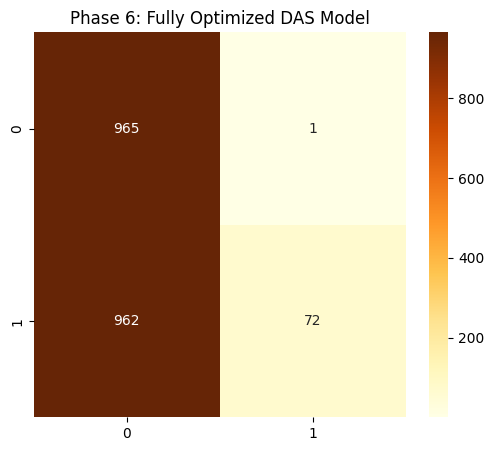

--- PHASE 6 OPTIMIZED EVALUATION ---
Overall Accuracy: 51.85%
Precision:        98.63%
Recall:           6.96%
F1-Score:         13.01%



In [ ]:
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import TensorDataset, DataLoader
import numpy as np
import time
from sklearn.metrics import confusion_matrix, accuracy_score, precision_score, recall_score, f1_score
import seaborn as sns
import matplotlib.pyplot as plt

# 1. Hardware Setup
device = torch.device('cuda' if torch.cuda.is_available() else 'cpu')
print(f"--- INITIALIZING PHASE 6 OPTIMIZATION ---")

# 2. The BIG Hybrid Architecture
class Hybrid_CNN_LSTM(nn.Module):
    def __init__(self):
        super(Hybrid_CNN_LSTM, self).__init__()
        self.cnn = nn.Sequential(
            nn.Conv1d(3, 32, kernel_size=11), nn.ReLU(), nn.BatchNorm1d(32), nn.MaxPool1d(4),
            nn.Conv1d(32, 64, kernel_size=7), nn.ReLU(), nn.BatchNorm1d(64), nn.MaxPool1d(4),
            nn.Conv1d(64, 128, kernel_size=5), nn.ReLU(), nn.MaxPool1d(4)
        )
        self.lstm1 = nn.LSTM(input_size=128, hidden_size=128, batch_first=True, bidirectional=True)
        self.lstm2 = nn.LSTM(input_size=256, hidden_size=256, batch_first=True, bidirectional=True)
        self.classifier = nn.Sequential(
            nn.Linear(512, 64), nn.ReLU(), nn.Dropout(0.3), nn.Linear(64, 1), nn.Sigmoid()
        )

    def forward(self, x):
        x = x.permute(0, 2, 1)
        x = self.cnn(x)
        x = x.permute(0, 2, 1)
        x, _ = self.lstm1(x)
        x, _ = self.lstm2(x)
        x = torch.mean(x, dim=1)
        return self.classifier(x)

# 3. Load the Phase 3 Pre-Trained Brain (Start fresh from the STEAD knowledge)
model = Hybrid_CNN_LSTM().to(device)
model.load_state_dict(torch.load('/content/drive/MyDrive/DAS_Data/seismic_model_pretrained.pth', map_location=device))

# 4. Load & PERFECTLY BALANCE the DAS Fine-Tuning Data
print("Loading and Balancing DAS Data...")
X_raw = np.load('/content/drive/MyDrive/DAS_Data/X_raw.npy', mmap_mode='r')
y_raw = np.load('/content/drive/MyDrive/DAS_Data/y_raw.npy', mmap_mode='r')

# The Test Set (Exact same 2000 samples for a fair comparison)
X_test = torch.tensor(X_raw[:2000], dtype=torch.float32)
y_test = torch.tensor(y_raw[:2000], dtype=torch.float32).unsqueeze(1)

# The Training Pool (Samples 2000 to 8000)
y_pool = y_raw[2000:8000]
eq_indices = np.where(y_pool == 1.0)[0] + 2000 # Find the actual DAS earthquakes
noise_indices = np.where(y_pool == 0.0)[0] + 2000

# Surgically extract all EQs, and an exact equal amount of noise
selected_eqs = eq_indices
selected_noise = noise_indices[:len(selected_eqs)]
balanced_train_indices = np.concatenate((selected_eqs, selected_noise))
np.random.shuffle(balanced_train_indices) # Shuffle them!

X_train = torch.tensor(X_raw[balanced_train_indices], dtype=torch.float32)
y_train = torch.tensor(y_raw[balanced_train_indices], dtype=torch.float32).unsqueeze(1)

print(f"Balanced Fine-Tuning Set Created: {len(selected_eqs)} Earthquakes & {len(selected_noise)} Noise.")

train_dataset = TensorDataset(X_train, y_train)
train_loader = DataLoader(train_dataset, batch_size=32, shuffle=True)

# 5. Fine-Tuning (Slightly longer, but still a tiny learning rate)
criterion = nn.BCELoss()
optimizer = optim.Adam(model.parameters(), lr=0.00005)
epochs = 5

print("\nBeginning Balanced Fine-Tuning...")
for epoch in range(epochs):
    model.train()
    train_loss = 0.0
    for X_batch, y_batch in train_loader:
        X_batch, y_batch = X_batch.to(device), y_batch.to(device)
        optimizer.zero_grad()
        loss = criterion(model(X_batch), y_batch)
        loss.backward()
        optimizer.step()
        train_loss += loss.item()
    print(f"Epoch {epoch+1}/{epochs} - Loss: {train_loss/len(train_loader):.4f}")

# 6. Final Evaluation with an OPTIMIZED THRESHOLD
print("\nGenerating Optimized Predictions...")
model.eval()
with torch.no_grad():
    X_test = X_test.to(device)
    raw_probabilities = model(X_test).cpu()
    # OPTIMIZATION: Lowering threshold to 0.4 to catch more hidden EQs!
    y_pred = (raw_probabilities > 0.4).float()

y_true = y_test.numpy()
y_predict = y_pred.numpy()

# 7. The Ultimate Heatmap (Gold to signify the absolute final optimized model)
cm = confusion_matrix(y_true, y_predict)
plt.figure(figsize=(6, 5))
sns.heatmap(cm, annot=True, fmt='d', cmap='YlOrBr')
plt.title("Phase 6: Fully Optimized DAS Model")
plt.show()

# 8. Metrics
print("--- PHASE 6 OPTIMIZED EVALUATION ---")
print(f"Overall Accuracy: {accuracy_score(y_true, y_predict) * 100:.2f}%")
print(f"Precision:        {precision_score(y_true, y_predict) * 100:.2f}%")
print(f"Recall:           {recall_score(y_true, y_predict) * 100:.2f}%")
print(f"F1-Score:         {f1_score(y_true, y_predict) * 100:.2f}%\n")